In [3]:
!pip install -U -q kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 5.1 MB/s eta 0:00:00


In [4]:
import os
os.environ["KAGGLE_API_TOKEN"] = "KGAT_9195aca583ed538d7a1b852e9e9bd101"

In [5]:
!kaggle datasets list

ref                                                             title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
datascikhan/e-commerce-sales-and-customer-analytics             E-Commerce Sales Analytics Dataset                    29815424  2026-08-25 08:00:46.013000           7288        153                1  
dreaddevelopment/raptor-knee-maxspan                            Knee MRI - Max-Span Dense Corpus                     271659195  2026-08-22 20:14:47.093000            797         28           0.8125  
srisyra02/online-food-ordering-dataset                          Online Food Ordering Dataset                              3648  2026-08-23 15:26:25.483000           4929         82                1  


In [8]:
import os

print("Token exists:", bool(os.environ.get("KAGGLE_API_TOKEN")))
print("Token prefix:", os.environ["KAGGLE_API_TOKEN"][:5])

Token exists: True
Token prefix: KGAT_


In [10]:
!kaggle auth login


Go to the following link in your browser, and complete the sign-in prompts at Kaggle:

  https://www.kaggle.com/api/v1/oauth2/authorize?response_type=code&client_id=kagglesdk&redirect_uri=https%3A%2F%2Fwww.kaggle.com%2Faccount%2Fapi%2Foauth%2Ftoken&scope=resources.admin%3A%2A&state=9f5a1753-2845-4b28-bdcf-02a810d664fe&code_challenge=OGbn-ghocif_9S9tVqyOpPuHLoFC-HKnH9Y4Vfmb03Q%3D&code_challenge_method=S256&response_mode=query

Once finished, enter the verification code provided in your browser: CfDJ8OasvsPNS7VMiSwiBm2YVpMa_lBgUjiM0h9m59nbQq1sE3FSTDaHy9nZPvqh8mlaDQa4JB0-jCTJzM_NcUxFKBx8YZTxNik5M23DV_Os_DOmj2wHUYh6Ff3SGjQOAdgKY43L-sWH68oaXVxKx9RFzkN1reIq2P4rHNYhw2I6zCedB0tO4F64f11cH8CWNrBAWG1AzXu2zJEtKPIQou_YR2YpgZnVRWue_-Y30MXOQAYPqfS1uCfvZsBtQn7gNsarVX-sX1XfTELQUFA29-6QKBr2hjBuf39fZnx53VymPrVKtaQl-RT3xihGbFn1y43hhR89aDQV5gFQCqjnYHBE2MijXEtKZt6s

You are now logged in as [sonali181234]



In [12]:
!kaggle datasets files salader/dogsvscats

Next Page Token = CfDJ8OasvsPNS7VMiSwiBm2YVpMPDd_j5XqRqeGXBdx9rOhK8mrO8rLuZ987COWOrh5nb2IJua6hKo18PIaf-9Dbi0K1wogj5V1Bce2G82k2bIGRTjDSWU94IzaiWJ6eYBMI-mmDGGDddpAtiv-JIwqwByEsYPgnaO0
name                                 size  creationDate                
----------------------------------  -----  --------------------------  
catsvsdogs/test/cats/cat.10.jpg     34315  2018-11-30 16:24:00.334000  
catsvsdogs/test/cats/cat.10000.jpg  21944  2018-11-30 16:23:40.902000  
catsvsdogs/test/cats/cat.10001.jpg  27322  2018-11-30 16:23:52.622000  
catsvsdogs/test/cats/cat.10007.jpg  10328  2018-11-30 16:23:52.549000  
catsvsdogs/test/cats/cat.10017.jpg  20276  2018-11-30 16:23:52.548000  
catsvsdogs/test/cats/cat.10021.jpg  32474  2018-11-30 16:23:52.473000  
catsvsdogs/test/cats/cat.10026.jpg  38281  2018-11-30 16:23:40.904000  
catsvsdogs/test/cats/cat.10030.jpg  36213  2018-11-30 16:23:52.535000  
catsvsdogs/test/cats/cat.10033.jpg  14185  2018-11-30 16:23:48.951000  
catsvsdogs/test/cats/cat.1

In [13]:
!kaggle datasets download -d salader/dogsvscats

Dataset URL: https://www.kaggle.com/datasets/salader/dogsvscats
License(s): unknown
100% 1.06G/1.06G [00:12<00:00, 91.8MB/s]



In [14]:
import zipfile

with zipfile.ZipFile("dogsvscats.zip", "r") as zip_ref:
    zip_ref.extractall("/content")

In [15]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout
import matplotlib.pyplot as plt
import cv2

In [16]:
# Load the training dataset
train_ds = keras.utils.image_dataset_from_directory(
    directory='/content/train',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256)
)

# Load the validation dataset
validation_ds = keras.utils.image_dataset_from_directory(
    directory='/content/test',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256)
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [17]:
# ==========================================
# 3. DATA PREPROCESSING (NORMALIZATION)
# ==========================================
# Normalize pixel values from [0, 255] to [0, 1]
def process(image, label):
    image = tf.cast(image / 255., tf.float32)
    return image, label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [18]:
# ==========================================
# 4. CNN MODEL ARCHITECTURE
# ==========================================
model = Sequential()

# 1st Convolutional Block
model.add(Conv2D(32, kernel_size=(3, 3), padding='valid', activation='relu', input_shape=(256, 256, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

# 2nd Convolutional Block
model.add(Conv2D(64, kernel_size=(3, 3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

# 3rd Convolutional Block
model.add(Conv2D(128, kernel_size=(3, 3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

# Flattening and Fully Connected Layers
model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.1))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.1))

# Output Layer for Binary Classification
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [20]:
# ==========================================
# 5. MODEL COMPILATION & TRAINING
# ==========================================
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Execute training across 10 epochs
history = model.fit(train_ds, epochs=10, validation_data=validation_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 70s 92ms/step - accuracy: 0.6126 - loss: 1.2680 - val_accuracy: 0.6060 - val_loss: 0.6673
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 69s 88ms/step - accuracy: 0.7184 - loss: 0.5593 - val_accuracy: 0.5012 - val_loss: 2.0390
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 88ms/step - accuracy: 0.7604 - loss: 0.5007 - val_accuracy: 0.7618 - val_loss: 0.4909
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 94ms/step - accuracy: 0.8109 - loss: 0.4139 - val_accuracy: 0.7908 - val_loss: 0.4529
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 88ms/step - accuracy: 0.8425 - loss: 0.3545 - val_accuracy: 0.7784 - val_loss: 0.4907
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 94ms/step - accuracy: 0.8780 - loss: 0.2869 - val_accuracy: 0.7704 - val_loss: 0.6647
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 78s 87ms/step - accuracy: 0.9108 - loss: 0.2136 - val_accuracy: 0.7970 - val_loss: 0.5515
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.9445 - loss: 0.1421 - 

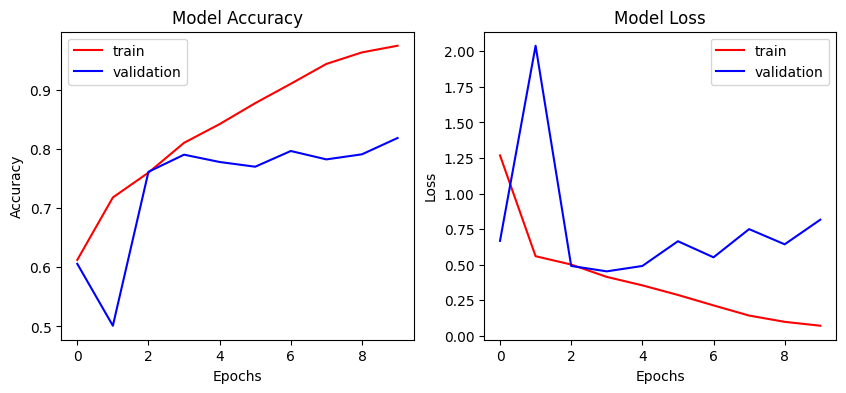

In [21]:
# ==========================================
# 6. EVALUATION (LOSS & ACCURACY PLOTS)
# ==========================================
# Plot Accuracy
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

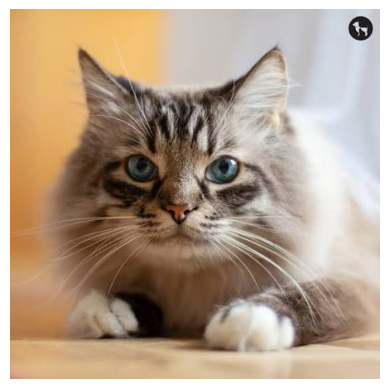

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Raw Prediction Value: 1.070429256344596e-08
Prediction: It's a CAT!


In [23]:

# ==========================================
# 7. INFERENCE (PREDICTING ON NEW IMAGES)
# ==========================================
# Replace path with your actual test image path (e.g., 'cat.jpg' or 'dog.jpg')
image_path = '/content/cat.jpg'

if os.path.exists(image_path):
    test_img = cv2.imread(image_path)
    # Convert BGR (OpenCV default) to RGB for correct matplotlib plotting
    test_img_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
    plt.imshow(test_img_rgb)
    plt.axis('off')
    plt.show()

    # Preprocess the image to fit model expectations
    test_img_resized = cv2.resize(test_img, (256, 256))
    test_input = test_img_resized.reshape((1, 256, 256, 3))

    # Scale image pixels if the training pipeline scales them
    test_input = test_input / 255.0

    # Prediction
    prediction = model.predict(test_input)
    print(f"Raw Prediction Value: {prediction[0][0]}")

    if prediction[0][0] < 0.5:
        print("Prediction: It's a CAT!")
    else:
        print("Prediction: It's a DOG!")
else:
    print(f"Image not found at {image_path}. Please check your path.")